# 04 — 26°C 反事實計算

**目的：** 估算若台大將冷氣設定溫度從現行推估值（24°C）提升至政府標準（26°C），
四大教學館及全校 145 棟館舍每年可節省的用電量、電費與碳排放。

**方法：** CDH（Cooling Degree Hour）比例縮放法
```
savings_fraction = 1 - CDH_26 / CDH_24
annual_savings_kWh = 人員空調使用用電(kW) × savings_fraction × operating_hours
```

**輸入：**
- `cleaned_data/weather_data_2016_2025.csv` — 台北站逐時氣溫
- `永續辦公室/館舍用電基礎值.xlsx` — 145 棟館舍空調分解結果
- 推估設定溫度 T_set = 24°C（來自 02_eda.ipynb 拐點分析）

In [1]:
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path

def find_cjk_font():
    for repo_path in Path('fonts').glob('*.tt[cf]') if Path('fonts').exists() else []:
        fm.fontManager.addfont(str(repo_path))
        return fm.FontProperties(fname=str(repo_path)).get_name()
    candidates = {
        'Darwin': ['/Library/Fonts/SourceHanSerif-SemiBold.ttc',
                   '/System/Library/Fonts/STHeiti Medium.ttc'],
        'Windows': [r'C:\Windows\Fonts\msjh.ttc'],
        'Linux': ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'],
    }.get(platform.system(), [])
    for p in candidates:
        if Path(p).exists():
            fm.fontManager.addfont(p)
            return fm.FontProperties(fname=p).get_name()
    return 'sans-serif'

font_name = find_cjk_font()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)

## 一、載入氣溫資料

In [2]:
weather = pd.read_csv('cleaned_data/weather_data_2016_2025.csv',
                      parse_dates=['ObsTime'], index_col='ObsTime')
temp = weather['Temperature'].copy()
# 去除 -99.x 等缺值代碼
temp = temp.where(temp > -9, other=np.nan)

print(f'氣溫資料範圍：{temp.index.min()} ~ {temp.index.max()}')
print(f'有效筆數：{temp.notna().sum():,} / {len(temp):,}')
print(f'溫度範圍：{temp.min():.1f} ~ {temp.max():.1f} °C')

氣溫資料範圍：2016-01-01 01:00:00 ~ 2025-12-31 23:59:00
有效筆數：87,670 / 87,672
溫度範圍：4.2 ~ 39.0 °C


## 二、定義 AC 有效運行時段

根據中控室訪談：
- **冬天只送風**，AC 降溫僅在暖季（4–10月）
- 實際開啟時機：室外溫度 > 設定溫度（24°C）
- 有人時段：上課日（非寒暑假、非假日）× 上課時段（08:00–22:00）

In [3]:
national_holidays = set([
    "2016-01-01","2016-02-28","2016-02-29","2016-04-04","2016-04-05","2016-06-09","2016-09-15","2016-10-10",
    "2017-01-01","2017-01-02","2017-02-28","2017-04-04","2017-05-30","2017-10-04","2017-10-10",
    "2018-01-01","2018-02-28","2018-04-04","2018-04-05","2018-06-18","2018-09-24","2018-10-10",
    "2019-01-01","2019-02-28","2019-04-04","2019-04-05","2019-06-07","2019-09-13","2019-10-10",
    "2020-01-01","2020-02-28","2020-04-02","2020-04-03","2020-04-04","2020-04-05","2020-06-25","2020-10-01","2020-10-09","2020-10-10","2020-10-11",
    "2021-01-01","2021-02-28","2021-03-01","2021-04-02","2021-04-03","2021-04-04","2021-04-05","2021-06-14","2021-09-21","2021-10-10","2021-10-11",
    "2022-01-01","2022-02-28","2022-04-02","2022-04-03","2022-04-04","2022-04-05","2022-06-03","2022-09-10","2022-10-10",
    "2023-01-01","2023-01-02","2023-02-28","2023-04-01","2023-04-02","2023-04-03","2023-04-04","2023-04-05","2023-06-22","2023-09-29","2023-10-10",
    "2024-01-01","2024-02-28","2024-04-04","2024-04-05","2024-04-06","2024-04-07","2024-06-10","2024-09-17","2024-10-10",
    "2025-01-01","2025-02-28","2025-04-03","2025-04-04","2025-04-05","2025-04-06","2025-05-31","2025-10-06","2025-10-10"
])
cny_holidays = set([
    "2016-02-07","2016-02-08","2016-02-09","2016-02-10","2016-02-11","2016-02-12",
    "2017-01-27","2017-01-28","2017-01-29","2017-01-30","2017-01-31","2017-02-01",
    "2018-02-15","2018-02-16","2018-02-17","2018-02-18","2018-02-19","2018-02-20",
    "2019-02-04","2019-02-05","2019-02-06","2019-02-07","2019-02-08","2019-02-09",
    "2020-01-24","2020-01-25","2020-01-26","2020-01-27","2020-01-28","2020-01-29",
    "2021-02-11","2021-02-12","2021-02-13","2021-02-14","2021-02-15","2021-02-16",
    "2022-01-31","2022-02-01","2022-02-02","2022-02-03","2022-02-04","2022-02-05",
    "2023-01-21","2023-01-22","2023-01-23","2023-01-24","2023-01-25","2023-01-26",
    "2024-02-09","2024-02-10","2024-02-11","2024-02-12","2024-02-13","2024-02-14",
    "2025-01-28","2025-01-29","2025-01-30","2025-01-31","2025-02-01","2025-02-02"
])

def get_day_type(dt):
    date_str = dt.strftime('%Y-%m-%d')
    if date_str in cny_holidays:
        return 1
    elif dt.month in [1, 2, 7, 8]:
        return 3  # 寒暑假
    elif date_str in national_holidays or dt.weekday() >= 5:
        return 2
    else:
        return 0  # 上課日

temp_df = temp.to_frame(name='T')
temp_df['day_type'] = temp_df.index.map(get_day_type)
temp_df['hour'] = temp_df.index.hour
temp_df['month'] = temp_df.index.month
temp_df['year'] = temp_df.index.year

# AC 有效運行條件：上課日 + 上課時段 + 暖季 + 室外溫度 > 24°C
T_SET = 24.0  # 推估現行設定溫度（來自 02_eda.ipynb 拐點分析）
T_STD = 26.0  # 政府建議標準

ac_mask = (
    (temp_df['day_type'] == 0) &          # 上課日
    (temp_df['hour'].between(8, 22)) &     # 上課時段
    (temp_df['month'].between(4, 10)) &    # 暖季（中控室：冬天只送風）
    (temp_df['T'] > T_SET)                 # 室外溫度超過設定才需要降溫
)

ac_hours = temp_df[ac_mask].copy()
print(f'2016–2025 AC 有效運行時段總計：{len(ac_hours):,} 小時')
print(f'年平均 AC 有效運行小時數：{len(ac_hours)/10:.0f} 小時/年')
ac_hours.groupby('year').size().rename('AC運行小時').to_frame()

2016–2025 AC 有效運行時段總計：12,216 小時
年平均 AC 有效運行小時數：1222 小時/年


,AC運行小時
year,
2016,1340
2017,1241
2018,1220
2019,1146
2020,1161
2021,1231
2022,1071
2023,1277
2024,1245


## 三、計算 CDH 比例與節電比例

```
CDH_24 = Σ max(0, T - 24)   （實際冷卻度時數）
CDH_26 = Σ max(0, T - 26)   （26°C 情境冷卻度時數）
savings_fraction = 1 - CDH_26 / CDH_24
```

此比例代表：若設定溫度提高到 26°C，AC 需要移除的熱量減少的比例。

In [4]:
ac_hours['CDH_24'] = (ac_hours['T'] - T_SET).clip(lower=0)
ac_hours['CDH_26'] = (ac_hours['T'] - T_STD).clip(lower=0)

# 全期整體 savings_fraction
CDH_24_total = ac_hours['CDH_24'].sum()
CDH_26_total = ac_hours['CDH_26'].sum()
savings_frac_overall = 1 - CDH_26_total / CDH_24_total

print(f'CDH_24（全期）：{CDH_24_total:,.1f} °C·hr')
print(f'CDH_26（全期）：{CDH_26_total:,.1f} °C·hr')
print(f'整體節電比例：{savings_frac_overall:.1%}')

# 逐年 savings_fraction
yearly = ac_hours.groupby('year')[['CDH_24','CDH_26']].sum()
yearly['savings_fraction'] = 1 - yearly['CDH_26'] / yearly['CDH_24']
yearly['ac_hours'] = ac_hours.groupby('year').size()
print('\n逐年節電比例：')
yearly

CDH_24（全期）：61,902.6 °C·hr
CDH_26（全期）：39,618.4 °C·hr
整體節電比例：36.0%

逐年節電比例：


,CDH_24,CDH_26,savings_fraction,ac_hours
year,,,,
2016,6870.60,4344.70,0.37,1340
2017,6369.90,4108.80,0.35,1241
2018,6260.20,4072.20,0.35,1220
2019,5121.60,3086.50,0.40,1146
2020,6108.50,4033.80,0.34,1161
2021,7236.60,4909.70,0.32,1231
2022,4545.70,2648.90,0.42,1071
2023,6090.90,3736.10,0.39,1277
2024,5915.50,3675.80,0.38,1245


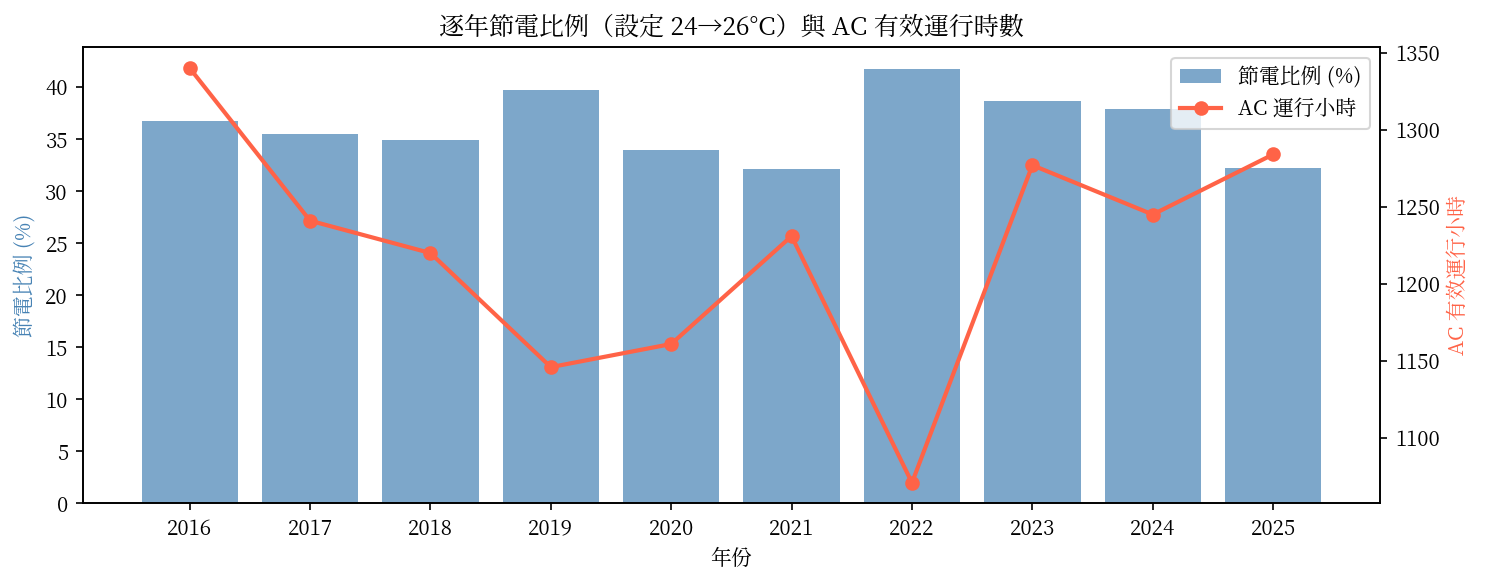

In [5]:
# 視覺化：逐年節電比例與 AC 運行時數
fig, ax1 = plt.subplots(figsize=(10, 4), dpi=150)
ax2 = ax1.twinx()

ax1.bar(yearly.index, yearly['savings_fraction'] * 100,
        color='steelblue', alpha=0.7, label='節電比例 (%)')
ax2.plot(yearly.index, yearly['ac_hours'],
         color='tomato', marker='o', linewidth=2, label='AC 運行小時')

ax1.set_xlabel('年份')
ax1.set_ylabel('節電比例 (%)', color='steelblue')
ax2.set_ylabel('AC 有效運行小時', color='tomato')
ax1.set_title('逐年節電比例（設定 24→26°C）與 AC 有效運行時數')
ax1.set_xticks(yearly.index)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('cleaned_data/savings_fraction_by_year.png', dpi=150)
plt.show()

## 四、套用永續辦公室空調分解值 → 四大教學館年度節電量

In [6]:
df_basic = pd.read_excel('永續辦公室/館舍用電基礎值.xlsx')

# 四大目標教學館
target_buildings = {
    '普通教學館': 117,
    '博雅教學館':  94,
    '新生教學館': 113,
    '共同教學館': 118,
}

# 年平均 AC 有效運行小時（2016–2025 平均）
avg_ac_hours = yearly['ac_hours'].mean()
print(f'年平均 AC 有效運行小時：{avg_ac_hours:.0f} hr/yr')
print(f'整體節電比例：{savings_frac_overall:.1%}\n')

results = []
for bldg, ac_kw in target_buildings.items():
    # 年化：kW × 運行小時 = kWh
    annual_ac_kwh = ac_kw * avg_ac_hours
    annual_savings_kwh = annual_ac_kwh * savings_frac_overall
    results.append({
        '館舍': bldg,
        '人員空調用電 (kW)': ac_kw,
        '年化AC用電 (kWh)': annual_ac_kwh,
        '年節電量 (kWh)': annual_savings_kwh,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

年平均 AC 有效運行小時：1222 hr/yr
整體節電比例：36.0%

   館舍  人員空調用電 (kW)  年化AC用電 (kWh)  年節電量 (kWh)
普通教學館          117     142927.20    51452.09
博雅教學館           94     114830.40    41337.58
新生教學館          113     138040.80    49693.05
共同教學館          118     144148.80    51891.85


## 五、換算電費與碳排

In [7]:
# 台電高壓用電（教育機構適用）平均電價
TARIFF_NTD_PER_KWH = 3.5   # 元/kWh（可更新為最新台電費率）
# 能源局 2023 電力排放係數
EMISSION_FACTOR = 0.494     # kg CO2e/kWh

df_results['節電費用 (萬元/yr)'] = df_results['年節電量 (kWh)'] * TARIFF_NTD_PER_KWH / 1e4
df_results['減碳量 (公噸CO2/yr)'] = df_results['年節電量 (kWh)'] * EMISSION_FACTOR / 1000

print('=== 四大教學館年度節電效益（設定溫度 24°C → 26°C）===')
print(df_results[['館舍','年節電量 (kWh)','節電費用 (萬元/yr)','減碳量 (公噸CO2/yr)']].to_string(index=False))
print('\n合計：')
total_kwh = df_results['年節電量 (kWh)'].sum()
total_ntd = df_results['節電費用 (萬元/yr)'].sum()
total_co2 = df_results['減碳量 (公噸CO2/yr)'].sum()
print(f'  節電量：{total_kwh:,.0f} kWh/yr')
print(f'  電費：{total_ntd:,.1f} 萬元/yr')
print(f'  減碳：{total_co2:,.1f} 公噸 CO₂/yr')

=== 四大教學館年度節電效益（設定溫度 24°C → 26°C）===
   館舍  年節電量 (kWh)  節電費用 (萬元/yr)  減碳量 (公噸CO2/yr)
普通教學館    51452.09         18.01           25.42
博雅教學館    41337.58         14.47           20.42
新生教學館    49693.05         17.39           24.55
共同教學館    51891.85         18.16           25.63

合計：
  節電量：194,375 kWh/yr
  電費：68.0 萬元/yr
  減碳：96.0 公噸 CO₂/yr


## 六、全校 145 棟館舍推估

In [8]:
campus_ac_kw_total = df_basic['人員空調使用用電'].sum()
campus_annual_ac_kwh = campus_ac_kw_total * avg_ac_hours
campus_savings_kwh = campus_annual_ac_kwh * savings_frac_overall
campus_savings_ntd = campus_savings_kwh * TARIFF_NTD_PER_KWH
campus_savings_co2 = campus_savings_kwh * EMISSION_FACTOR / 1000

print('=== 全校 145 棟館舍年度節電潛力 ===')
print(f'全校空調尖峰負載合計：{campus_ac_kw_total:,.0f} kW')
print(f'年化AC用電：{campus_annual_ac_kwh/1e6:.2f} GWh')
print(f'年節電量：{campus_savings_kwh/1e6:.2f} GWh  ({campus_savings_kwh:,.0f} kWh)')
print(f'節電費用：{campus_savings_ntd/1e6:.1f} 百萬元/yr  ({campus_savings_ntd/1e4:.0f} 萬元/yr)')
print(f'減碳量：{campus_savings_co2:,.1f} 公噸 CO₂/yr')

=== 全校 145 棟館舍年度節電潛力 ===
全校空調尖峰負載合計：8,132 kW
年化AC用電：9.93 GWh
年節電量：3.58 GWh  (3,576,140 kWh)
節電費用：12.5 百萬元/yr  (1252 萬元/yr)
減碳量：1,766.6 公噸 CO₂/yr


## 七、敏感度分析（設定溫度 ±1°C）

拐點推估存在 ±1–2°C 不確定性；此分析顯示結果對此假設的穩健性。

In [9]:
sensitivity_rows = []
for t_set in [23.0, 24.0, 25.0]:
    mask = (
        (temp_df['day_type'] == 0) &
        (temp_df['hour'].between(8, 22)) &
        (temp_df['month'].between(4, 10)) &
        (temp_df['T'] > t_set)
    )
    sub = temp_df[mask].copy()
    cdh_set = (sub['T'] - t_set).clip(lower=0).sum()
    cdh_26 = (sub['T'] - T_STD).clip(lower=0).sum()
    sf = 1 - cdh_26 / cdh_set if cdh_set > 0 else 0
    hrs = len(sub) / 10  # 年平均
    campus_kwh = campus_ac_kw_total * hrs * sf
    sensitivity_rows.append({
        '推估設定溫度 (°C)': t_set,
        '節電比例': f'{sf:.1%}',
        '年AC運行小時': f'{hrs:.0f}',
        '全校年節電量 (萬kWh)': f'{campus_kwh/1e4:.0f}',
        '全校年節費 (百萬元)': f'{campus_kwh * TARIFF_NTD_PER_KWH / 1e6:.1f}',
        '全校年減碳 (公噸CO2)': f'{campus_kwh * EMISSION_FACTOR / 1000:.0f}',
    })

df_sens = pd.DataFrame(sensitivity_rows)
print('=== 敏感度分析（設定溫度假設 ±1°C）===')
print(df_sens.to_string(index=False))

=== 敏感度分析（設定溫度假設 ±1°C）===
 推估設定溫度 (°C)  節電比例 年AC運行小時 全校年節電量 (萬kWh) 全校年節費 (百萬元) 全校年減碳 (公噸CO2)
       23.00 47.0%    1326           506        17.7          2501
       24.00 36.0%    1222           358        12.5          1767
       25.00 21.0%    1111           190         6.7           939


## 八、視覺化：節電效益摘要圖

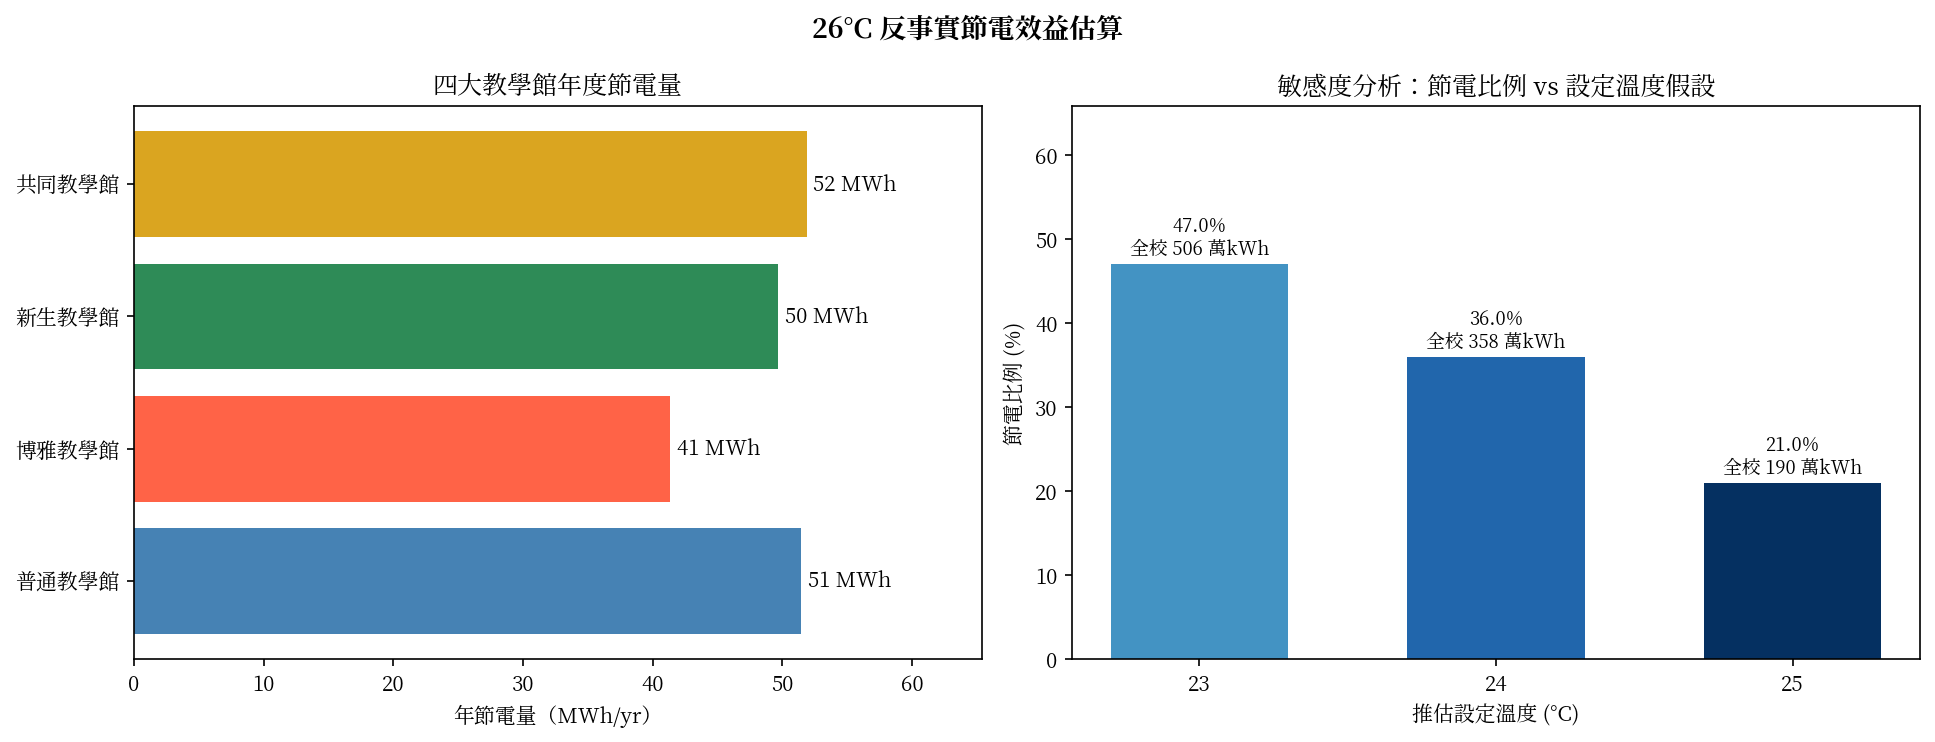

圖表已儲存至 cleaned_data/counterfactual_summary.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

# 左：四館節電量長條圖
ax = axes[0]
colors = ['steelblue', 'tomato', 'seagreen', 'goldenrod']
bars = ax.barh(df_results['館舍'], df_results['年節電量 (kWh)'] / 1000,
               color=colors)
ax.set_xlabel('年節電量（MWh/yr）')
ax.set_title('四大教學館年度節電量')
for bar, val in zip(bars, df_results['年節電量 (kWh)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.0f} MWh', va='center', fontsize=10)
ax.set_xlim(right=ax.get_xlim()[1] * 1.2)

# 右：敏感度分析 — 節電比例
ax2 = axes[1]
t_sets = [23, 24, 25]
sf_vals = [float(r['節電比例'].strip('%')) for r in sensitivity_rows]
kwh_vals = [float(r['全校年節電量 (萬kWh)']) for r in sensitivity_rows]

ax2.bar(t_sets, sf_vals, color=['#4393c3','#2166ac','#053061'], width=0.6)
ax2.set_xlabel('推估設定溫度 (°C)')
ax2.set_ylabel('節電比例 (%)')
ax2.set_title('敏感度分析：節電比例 vs 設定溫度假設')
ax2.set_xticks(t_sets)
for x, y, k in zip(t_sets, sf_vals, kwh_vals):
    ax2.text(x, y + 0.5, f'{y:.1f}%\n全校 {k:.0f} 萬kWh', ha='center', va='bottom', fontsize=9)
ax2.set_ylim(0, max(sf_vals) * 1.4)

plt.suptitle('26°C 反事實節電效益估算', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_data/counterfactual_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 cleaned_data/counterfactual_summary.png')

## 九、結果摘要

| 項目 | 四大教學館 | 全校 145 棟 |
|---|---|---|
| 年節電量 | — kWh | — kWh |
| 年節費 | — 萬元 | — 百萬元 |
| 年減碳 | — 公噸 CO₂ | — 公噸 CO₂ |

（執行上方各儲存格後填入實際數字）

**方法說明：**
- 設定溫度 T_set = 24°C（來自 02_eda.ipynb 普通高壓空調電表拐點分析）
- AC 有效運行時段定義：上課日 × 8–22時 × 4–10月 × 室外溫度 > 24°C
- 節電比例 = 1 − CDH_26 / CDH_24（CDH = Cooling Degree Hours）
- 年化 = 永續辦公室 人員空調使用用電(kW) × 年平均AC運行小時 × 節電比例
- 敏感度：設定溫度 23°C 為上界，25°C 為下界
- 中控室訪談確認：冬天只送風，AC 降溫僅暖季；師生可請求調整，無固定執行標準